<a href="https://colab.research.google.com/github/ChrisJavier/UIDE_3_WorkGroupDataMinning/blob/main/Week01/WorkGroup/DAMI_CP_W1_E10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Trabajo 1: Análisis Exploratorio de Datos – Adult Income Dataset


## 📋 Información del Proyecto
- Autores:
  - CARRERA DIAZ CHRISTIAN JAVIER
- Versión: 1.0.0
- Licencia: MIT


### **🎯 Introducción:**

El objetivo de esta tarea es realizar un análisis exploratorio de datos completo sobre el dataset Adult Income. Se deberá identificar patrones, relaciones y factores que influyen en el ingreso de las personas (>50K), y presentar sus hallazgos en un notebook y un PDF resumen.

### **🌍 Contexto del trabajo**

El dataset Adult Income contiene información de censos de individuos incluyendo edad, educación, sexo, horas trabajadas, ocupación, ganancias y pérdidas de capital, entre otras variables. La variable objetivo es 'income' (<=50K, >50K)

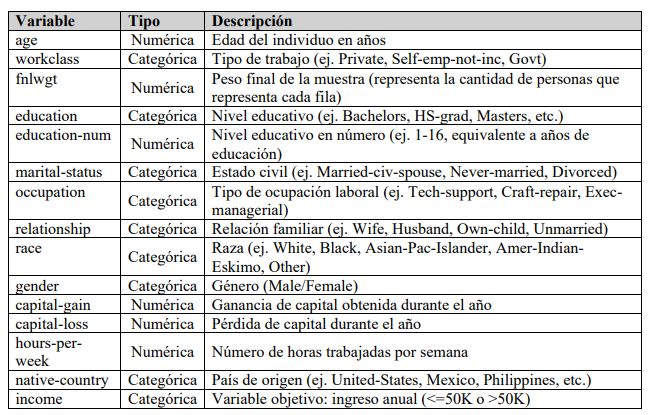

### **✅ Objetivos**

1️⃣ Cargar y preparar los datos.

2️⃣ Realizar estadísticas descriptivas de variables numéricas y categóricas.

3️⃣ Analizar distribuciones univariadas y detectar outliers.

4️⃣ Explorar relaciones bivariadas entre variables y la variable objetivo.

5️⃣ Generar gráficos tipo subplot, boxplots, countplots e histogramas.

6️⃣ Calcular la matriz de correlación y visualizarla con heatmap.

7️⃣ Identificar hallazgos y conclusiones relevantes.

8️⃣ Presentar el trabajo en un notebook y un PDF resumen con gráficos y
conclusiones.

# 🏗️ Carga y preparación de datos

*******************************************************************************

## 🔗 Enlaces del Dataset que se usaran

La información que usaremos para esta práctica es un dataset proporcionado por el docente que estará disponible en el siguiente enlace: https://raw.githubusercontent.com/ChrisJavier/UIDE_3_WorkGroupDataMinning/refs/heads/main/Week01/WorkGroup/dataset/adult.csv


## 🚀 Descarga del dataset

In [6]:
 # importacion de la libreria os que permite interactuar con el sistema operativo (archivos y rutas)

import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define el nombre del archivo csv que se descargará
adult_file_path = 'adult.csv'

# Descarga el archivo csv del dataset
# El archivo se guarda en el entorno de trabajo actual y valido que si existe no lo descargue de nuevo

if not os.path.exists(adult_file_path) and not os.path.exists(adult_file_path):
  !wget --timeout=15 --tries=2 'https://raw.githubusercontent.com/ChrisJavier/UIDE_3_WorkGroupDataMinning/refs/heads/main/Week01/WorkGroup/dataset/adult.csv' -O '{adult_file_path}'
  print(f'Archivo {adult_file_path} descargado')
else:
  print(f'Archivo {adult_file_path} ya existe')

# Cargamos el archivo csv para continuar con el ejercicio
df = pd.read_csv(adult_file_path)

Archivo adult.csv ya existe


## 🚀 Previsualizacion y validacion

📥 Se valida los datos que tenemos actualmente y visualizamos sus columnas y sus tipos de datos

In [7]:
# Visualizamos un breve informacion del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


# *🔍* Estadísticas descriptivas

En esta sección analizaremos las columnas por su tipo de dato e interpretaremos su contenido.

En las columnas numericas tenemos un conteo de 48842 registros en el conjunto de datos donde las columnas que son númericas son: **age, fnlwgt, educational-num,	capital-gain, capital-loss, hours-per-week**. Las cuales ya teniamos un primer vistazo en la tabla que se nos fue brindada para este trabajo. A continuación interpretaremos el conjunto de datos:

- **En la columna edad**: podemos notar que la edad media es de 38,6 años, la persona de menor edad es de 17 años y la edad máxima es de 90 años que nos dice que pueden existir outliers debido a esta diferiencia de edad.

- **El peso final** al ser un valor de ponderación de este censo que por ello no se tomará  en cuenta.

- **El nivel educativo de las personas censadas** esta en promedio de 10 años con un maximo de 16 años que existe personas muy preparadas y notando el minimo de 1 año quiere decir que tenemos personas que apenas pudieron estudiar.

- **El capital ganado** miramos que tenemos un máximo con un valor que no puede ser real, parece un valor de relleno que puede tomarse como un outlier, por otro lado el promedio de ganancias de las personas de este censo es de $ 1079 y una mínima de 0. Al revisar estos datos nos puede decir que tenemos un dataset muy variado que puede contener outliers que pueden afectar a nuestro analisis.

- **El capital perdido** nos muestra que tenemos una media de perdida de $87, una mínima de $0 y una maxima de $4356 que nos dice que estas personas casi no perdieron dinero pero la máxima llama la atención por lo exhuberante cantidad que expone y tendriamos que analizar ese caso.

- **En las horas trabajadas** tenemos una media de 40 horas por semana, el minimo es de 1 hora y un máximo nos dice que es 99 horas. El valor máximo llama la atención debido a la que es un valor irreal pero eso tenemos que analizarlo en otra sección.



In [8]:
# Muestra un resumen estadístico de las columnas numéricas del dataset
df.describe(include='number')

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


Por otro lado, para los objetos tenemos una estadistica diferente que nos hace resaltar otras interpretaciones, pero la cantidad de registros se mantiene como en la anterior revisión. Las columnas de tipo de dato objeto tenemos: **workclass, education, marital-status, occupation, relationship, race, gender	native-country,	income**. A continuación interpretaremos los datos:


- **En el tipo de trabajo**: Existen 9 categorias en esta columna que la más comun es Private que aparece al menos 33906.
- **En el nivel educativo**: Existen 16 categorias de las cuales "HS-grad" es el más común con una frecuencia de 15784.
- **En el estado civil**: Existen 7 categorias donde la categoria "Married-civ-spouse" con una frecuencia de 22379.
- **En la ocupación**: Existen 15 categorias donde la categoria "Prof-specialty" es la más fecuente con una frecuencia 6172 veces.
- **La relación familiar**: Existe 6 categorias donde la categoria más comun es "Husband" con una frecuencia de 19716.
- **La raza o étnia**: Existe 5 categorias donde la categoria es más frecuente es "White" con una frecuencia de 41762 que nos dice que la mayoria del dataset pertenece a esta étnia.
- **El género**: Existe 2 categorias donde la categoria más común es "Male" con una frecuencia de 32650.
- **El país de origen**: Existe 42 categorias donde la más común es "United-States" con una frecuencia de 43832, donde esto nos confirma que es un censo en la población americana.
- **Ingresos**: Existe 2 categorias donde la más frecuente es "<=50k" con una frecuencia de 37155 veces.

En conclusión, tenemos un conjunto de datos con varidad que nos permitirá realizar un analisis más completo, pero tenemos que revisar si existen registros faltantes en las columnas de categorias.



In [9]:
# Muestra un resumen estadístico de las columnas objetos
df.describe(include='object')

,workclass,education,marital-status,occupation,relationship,race,gender,native-country,income
count,48842,48842,48842,48842,48842,48842,48842,48842,48842
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,37155


## 🚀 Gráficos de cada columna por tipo de dato númerico

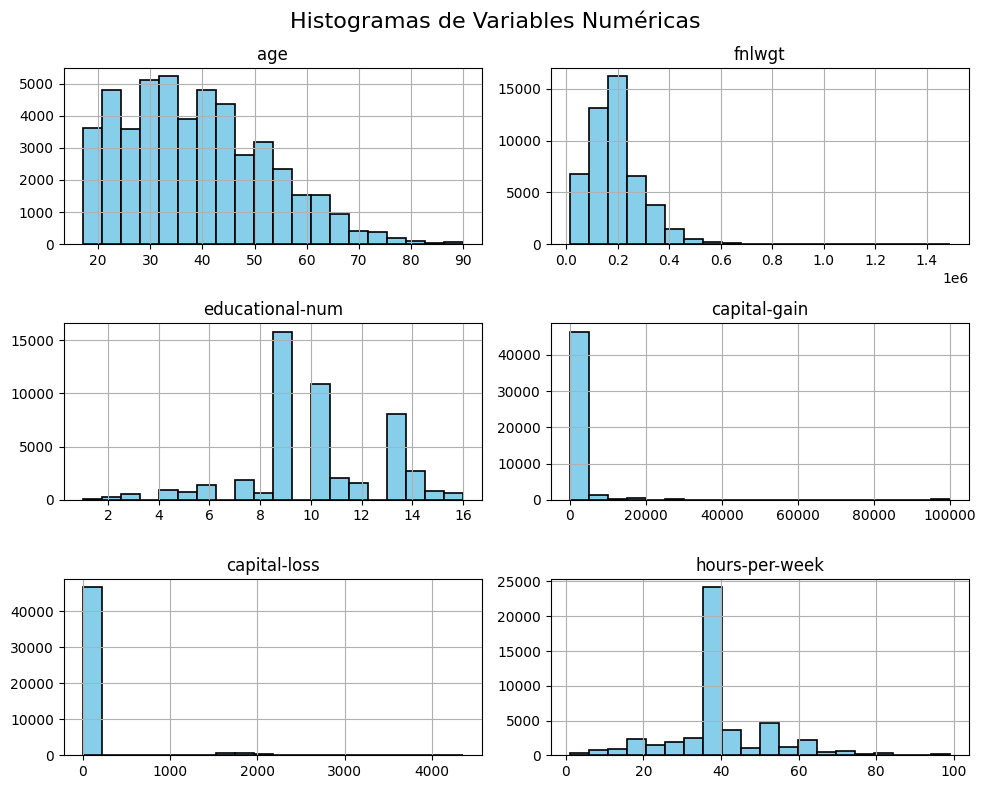

In [14]:
# Gráficamos las columnas en un histograma para el tipo de dato de number
# Seleccionar variables numéricas
df_num = df.select_dtypes(include='number')

# Histogramas
df_num.hist(figsize=(10,8),
            color='skyblue',      # Color de las barras
            edgecolor='black',    # Color del borde
            linewidth=1.2,         # Grosor del borde
            bins=20)

plt.suptitle("Histogramas de Variables Numéricas", fontsize=16)
plt.tight_layout()
plt.show()

## 🚀 Gráficos de cada columna por tipo de dato objeto

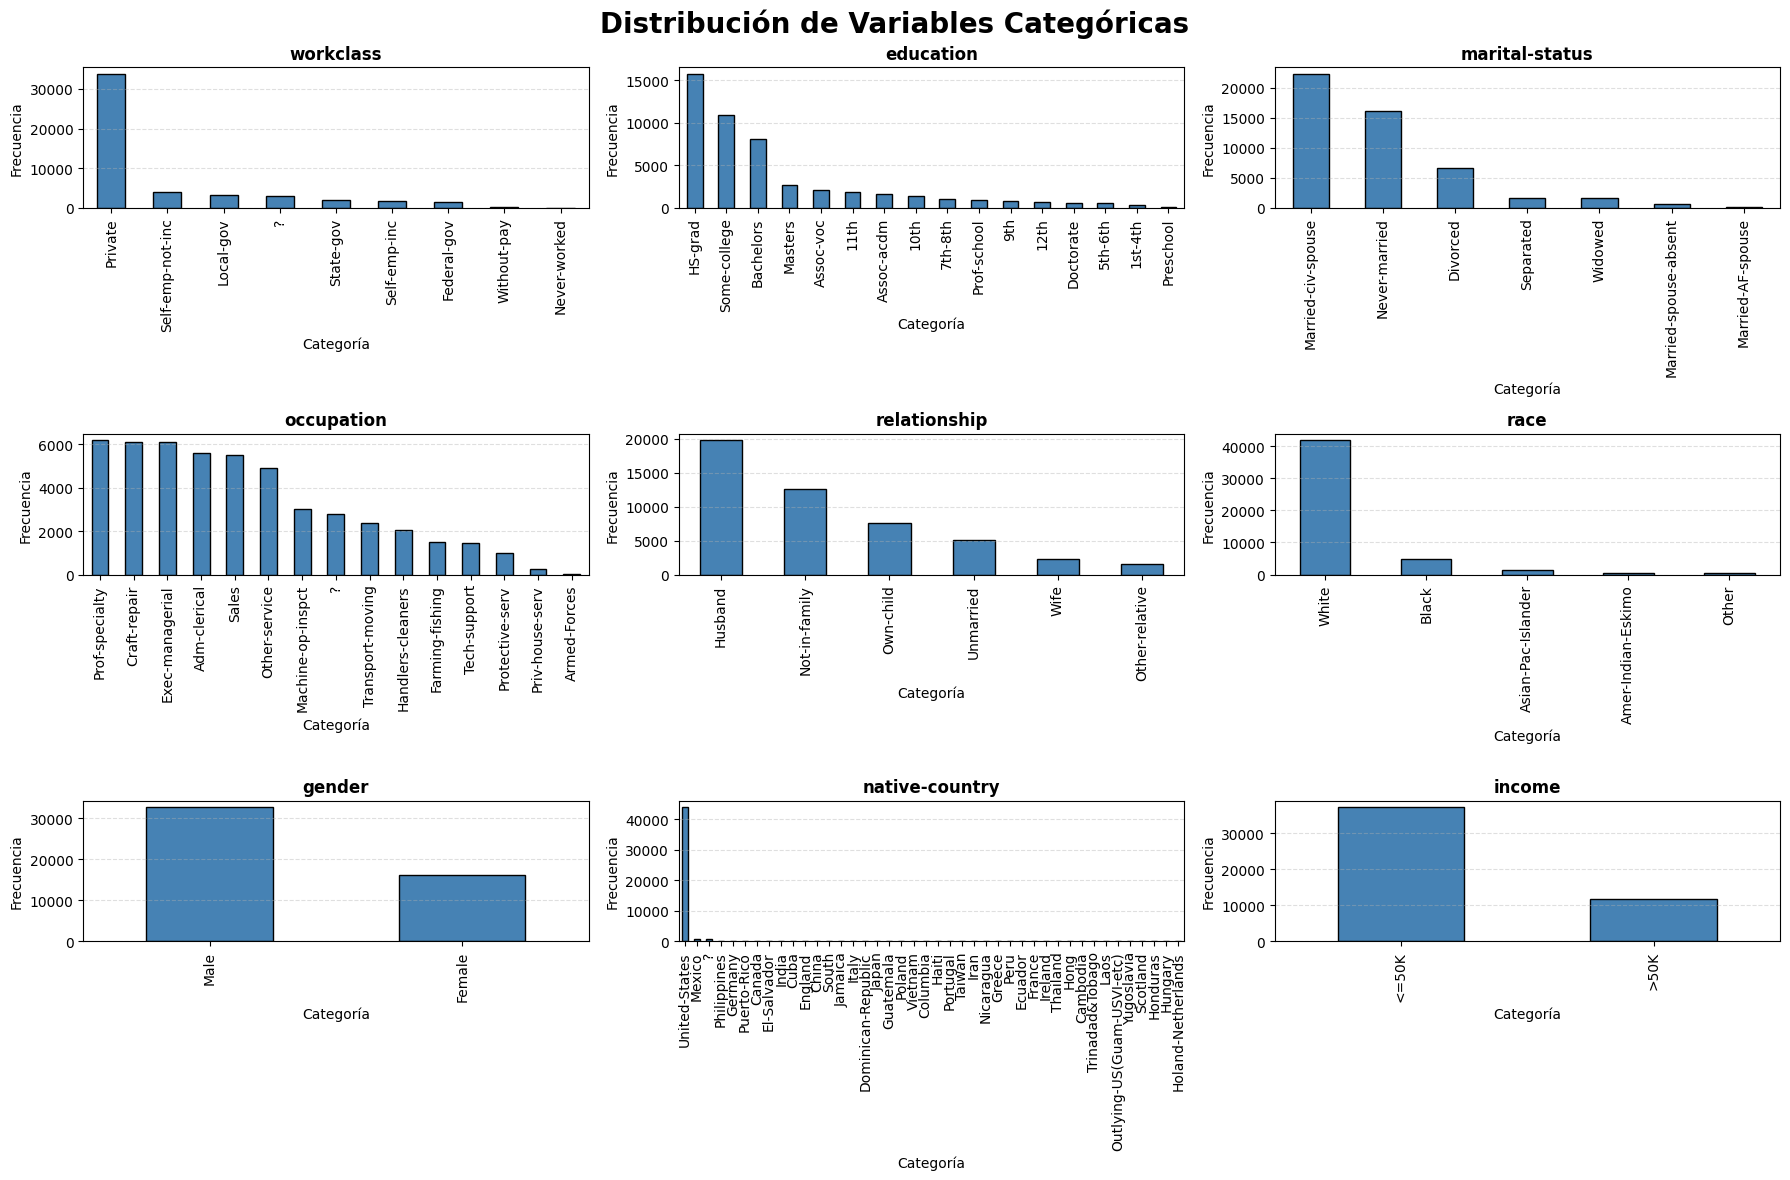

In [20]:
# Gráficamos las columnas en un histograma para el tipo de dato de object
# Variables categóricas
df_object = df.select_dtypes(include='object').columns

# Crear una cuadrícula de gráficos
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,12))

# Convertir la matriz de ejes en un vector
axes = axes.flatten()

# Dibujar cada gráfico
for i, col in enumerate(df_object):
    df[col].value_counts().plot(
        kind='bar',
        ax=axes[i],
        color='steelblue',
        edgecolor='black'
    )

    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Categoría")
    axes[i].set_ylabel("Frecuencia")
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

# Si sobran ejes, eliminarlos
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribución de Variables Categóricas", fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

## 🚀 Limpieza y Exploración Inicial:

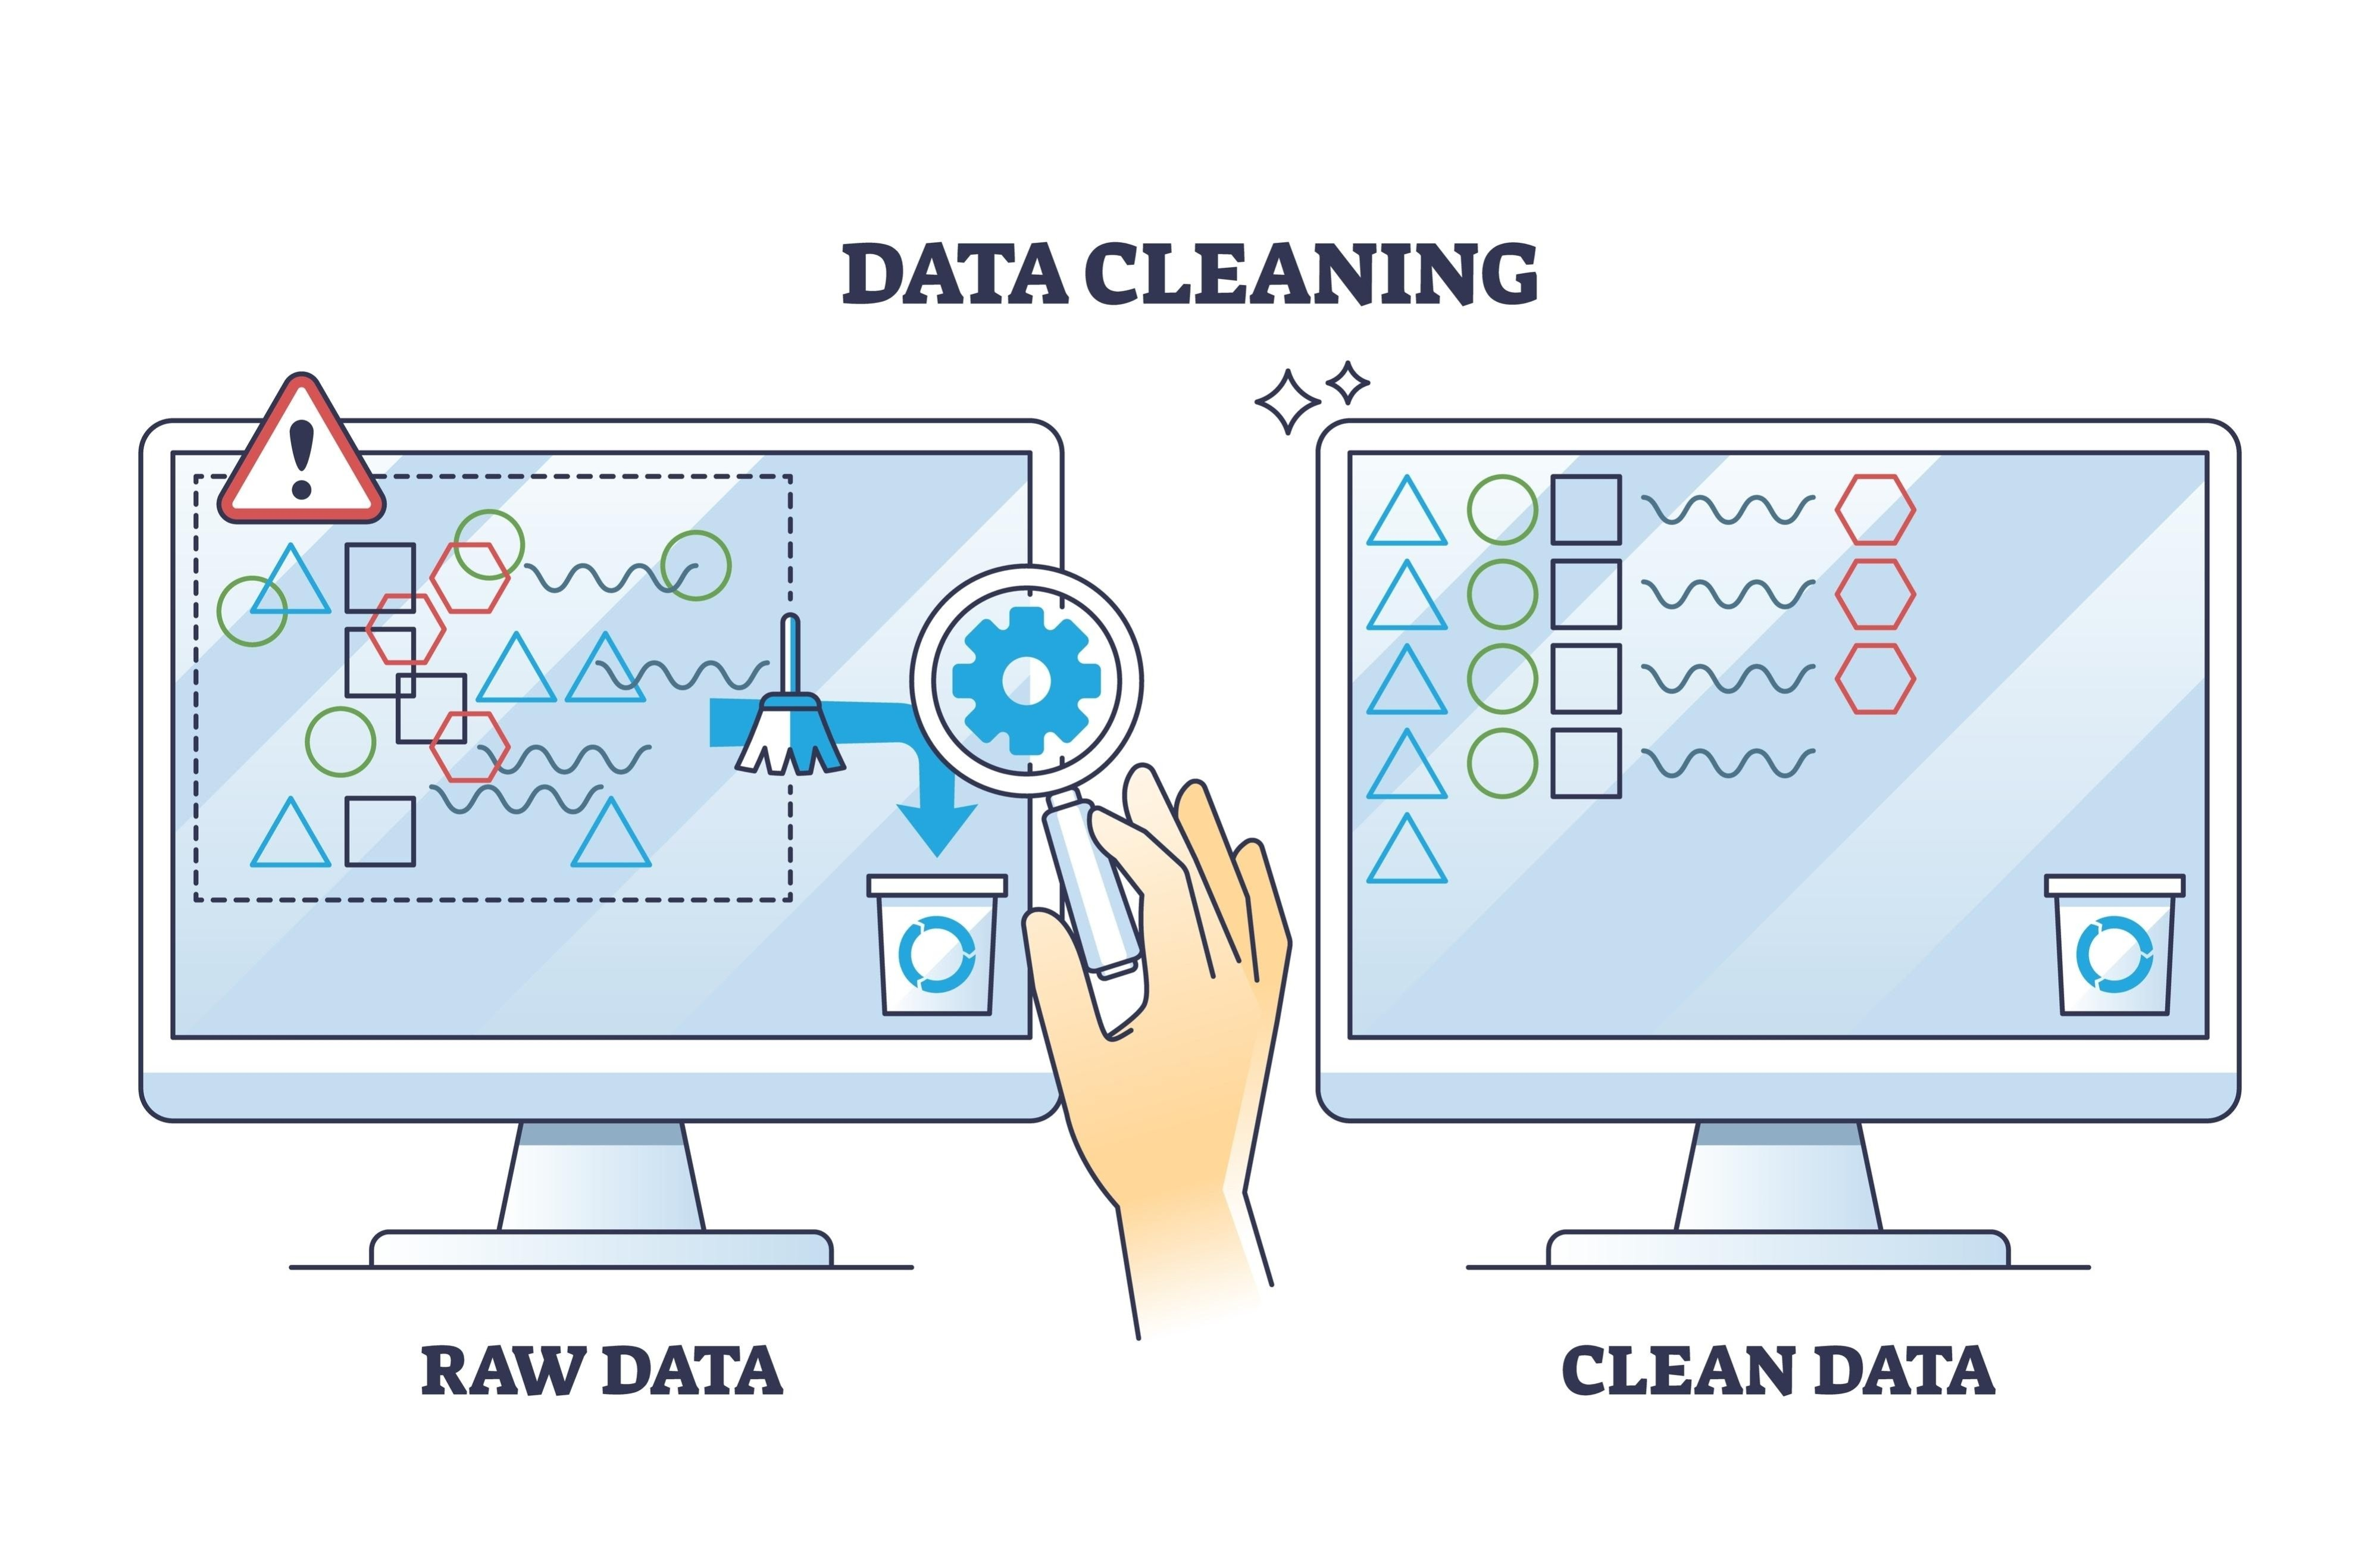

## 🚀 Tratamiento de Valores Nulos
Para garantizar que el análisis sea estadísticamente significativo y técnicamente eficiente, se han aplicado las siguientes reglas de procesamiento sobre el dataset:

Identificar las columnas que presentan más del 30 % de valores nulos para decidir su eliminación.
Adicional, se reviso las columnas por la varianza para eliminar aquellas que no sean necesarias.
En el caso de columnas críticas con pocos valores faltantes, se realiza la imputación de datos.

El código **analiza los valores nulos**, elimina las columnas con **más del 30 % de datos faltantes** y muestra un **comparativo del número de columnas antes y después** del proceso de limpieza.


In [ ]:
# Obtiene el número total de columnas del DataFrame original
total_columnas_antes = df.shape[1]
total_columnas_antes  # Muestra el total de columnas antes del tratamiento

# Calcula el porcentaje de valores nulos por cada columna
nulos = (
    df.isna()          # Identifica valores nulos (NaN)
      .mean()          # Calcula la proporción de nulos por columna
      .mul(100)        # Convierte la proporción a porcentaje
      .round(2)        # Redondea a 2 decimales
      .reset_index()   # Convierte el índice en una columna
)

# Renombra las columnas del DataFrame resultante
nulos.columns = ['Columna', 'Porcentaje_nulos']

# Selecciona las columnas que tienen más del 30% de valores nulos
columnas_mayor_30 = (
    nulos[nulos['Porcentaje_nulos'] > 30]['Columna']
    .tolist()          # Convierte los nombres de columnas a una lista
)

# Elimina del DataFrame las columnas con más del 30% de nulos
df_reducido = df.drop(columns=columnas_mayor_30)

# "Las columnas que tienen un valor único... probablemente sean inútiles"
for col in df_reducido.columns:
    if df_reducido[col].nunique() == 1:
        print(f"Eliminando columna de varianza cero: {col}")
        df_reducido = df_reducido.drop(columns=[col])

print(f"Dimensiones post-limpieza básica: {df_reducido.shape}")

# Obtiene el total de columnas después de eliminar las columnas con muchos nulos
total_columnas_despues = df_reducido.shape[1]
total_columnas_despues  # Muestra el total de columnas después del tratamiento

# Crea un DataFrame resumen con el antes y después del tratamiento de columnas
resumen_columnas = pd.DataFrame({
    'Estado': ['Antes del tratamiento', 'Después del tratamiento'],
    'Total_columnas': [total_columnas_antes, total_columnas_despues]
})

# Muestra el resumen final
resumen_columnas


Dimensiones post-limpieza básica: (569, 31)


,Estado,Total_columnas
0,Antes del tratamiento,31
1,Después del tratamiento,31


Luego de validar, nos percatamos que no existen columnas para eliminar.

### Filtrado por Umbral de Nulos (30%)
Se decidió eliminar automáticamente cualquier columna que presentara más del 30% de valores ausentes.
###¿Por qué?:
Una columna con un alto índice de nulos introduce sesgos y reduce la confiabilidad de cualquier modelo o gráfico. Al superar el 30%, la cantidad de datos "inventados" o imputados necesarios para rellenar.


### 🧠 Interpretación

La normalización era necesaria porque las variables que tiene el dataset son de escalas heterogenéneas, es decir que tienen escalas más dispersas porque son datos clinicos y de cara a un modelo que se desea entrenar podria tener problemas debido a esas escalar que serán relevantes para el modelo pero no tiene que ser asi. Al ser sencibles a la magnitud es mejor normalizarlos a valores que puedan ser interpretados correctamente para una correcta predicción.

# 🧪 Analisis Exploratorio (EDA) de Cáncer de Mama

En esta sección, vamos a realizar la interpretación de los datos proporcionados.

### 🚀 Matriz de correlacion

Generaremos una matriz de correlaccion con todas las columnas existentes en el dataset.

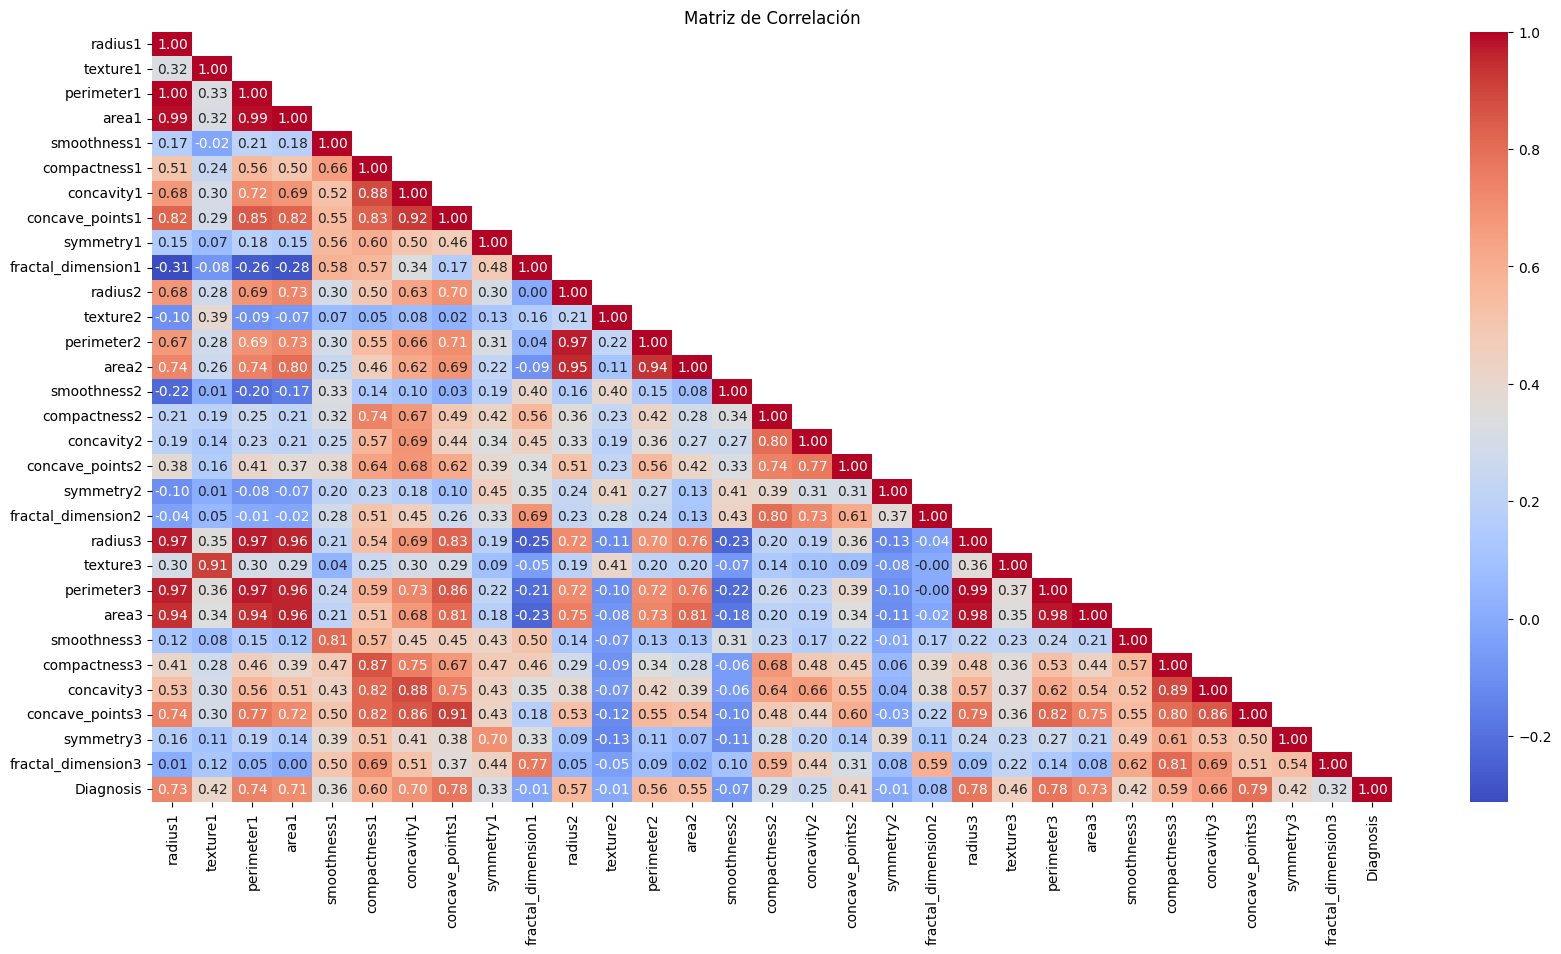

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Crearemos una matriz de correlaccion entre los valores

corr_matrix = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(20,10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Matriz de Correlación")
plt.show()


#### 🧠 Interpretación de Gráfico

El análisis de la matriz de correlación permitió identificar relaciones significativas entre las variables del dataset, evidenciando una fuerte dependencia entre características relacionadas con el tamaño y la forma de las células analizadas. Variables como radius, perimeter y area, especialmente en sus versiones 3 (worst), presentan correlaciones extremadamente altas entre sí, alcanzando valores cercanos a 1.00. Esto indica la presencia de multicolinealidad, ya que varias variables aportan información muy similar dentro del modelo.

Asimismo, se observó que las variables con mayor relación respecto al diagnóstico (Diagnosis) son concave_points3, perimeter3, radius3, area3 y concavity3, mostrando correlaciones positivas altas. Esto sugiere que las características geométricas más extremas o severas de las células tienen una fuerte influencia en la clasificación de tumores benignos y malignos, convirtiéndose en atributos relevantes para modelos predictivos.

Por otro lado, algunas variables como fractal_dimension2, smoothness2 y ciertas métricas de error presentan correlaciones bajas con el diagnóstico, lo que podría indicar una menor capacidad predictiva individual. En conjunto, la matriz confirma que el dataset posee patrones estructurados y consistentes, adecuados para aplicar técnicas de Machine Learning, aunque también evidencia la necesidad de considerar procesos de normalización y posible reducción de variables redundantes para optimizar el desempeño de los modelos.

### 🚀 Submatriz de correlacion

En esta submatriz tendremos filtrados las columnas con mayor correlacion para entender mejor este dataset.

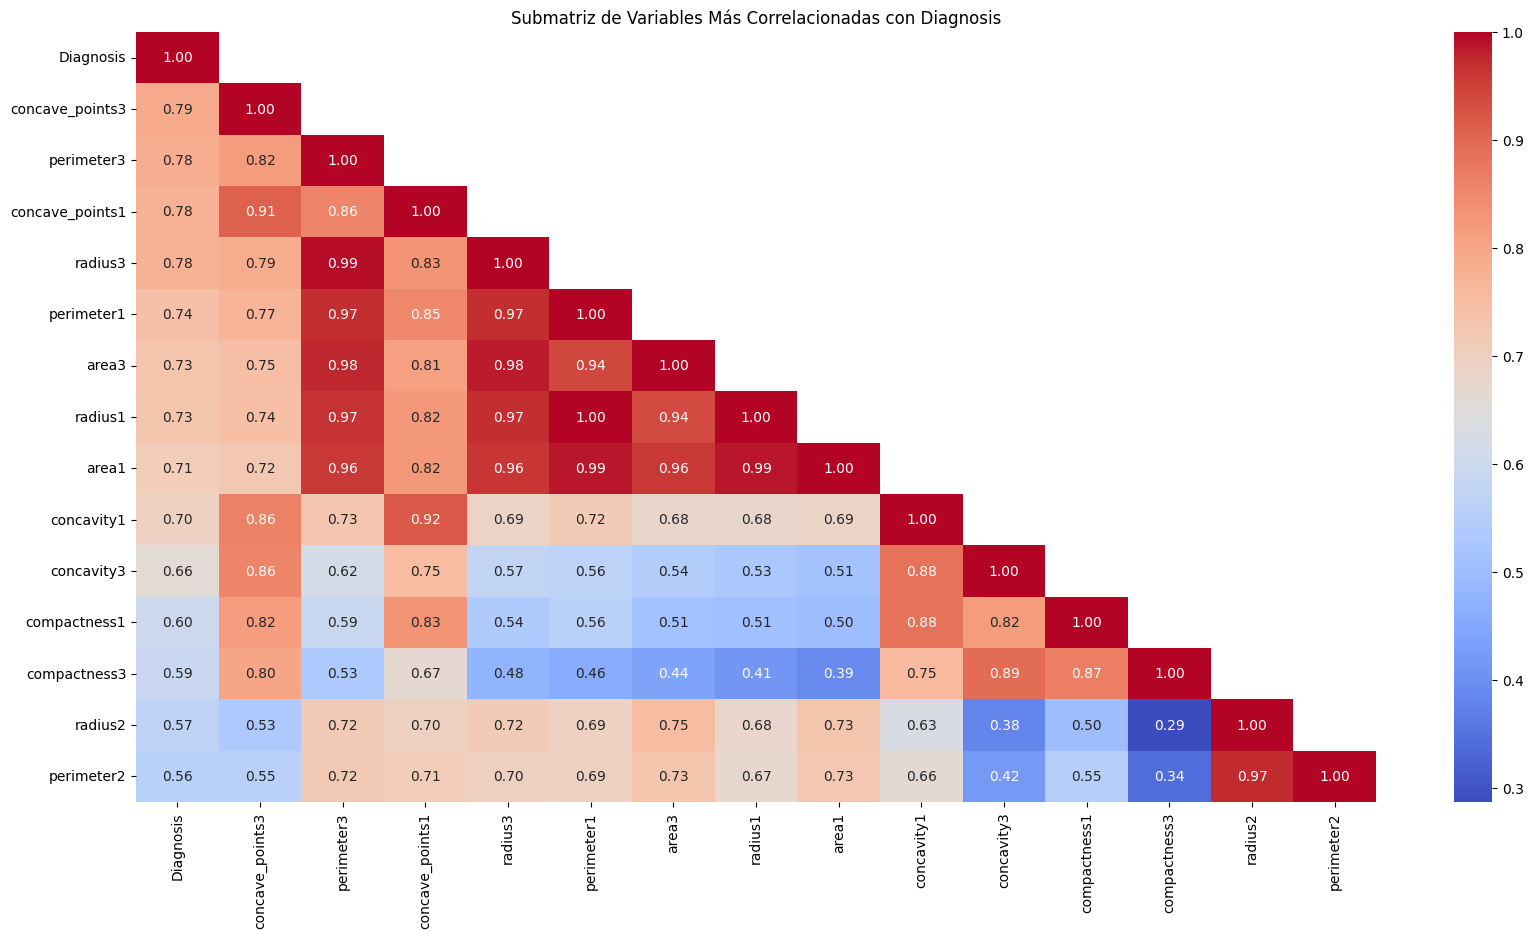

In [ ]:
# Obtener correlación con Diagnosis
top_corr = (
    corr_matrix["Diagnosis"]
    .abs()
    .sort_values(ascending=False)
)

# Elegir top 10 variables
top_variables = top_corr.head(15).index


# Crear submatriz
submatriz = corr_matrix.loc[top_variables, top_variables]

mask = np.triu(np.ones_like(submatriz, dtype=bool), k=1)

# Graficar
plt.figure(figsize=(20,10))

sns.heatmap(
    submatriz,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Submatriz de Variables Más Correlacionadas con Diagnosis")
plt.show()

#### 🧠 Interpretación de Gráfico

La submatriz de correlación permitió identificar una fuerte relación entre variables geométricas y morfológicas asociadas al diagnóstico. Las variables relacionadas con concavidad, perímetro y radio presentan las correlaciones más altas con tumores malignos, evidenciando un alto poder predictivo. Asimismo, se detectó multicolinealidad significativa entre variables de tamaño y forma, indicando redundancia de información y la necesidad de aplicar técnicas de selección o reducción de variables para optimizar futuros modelos de Machine Learning.

### 🚀 Distribución de clases

En este gráfico verificaremos si hay desbalance en los casos por el diagnostico.

/tmp/ipykernel_177/3441091432.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Benigno", "Maligno"])


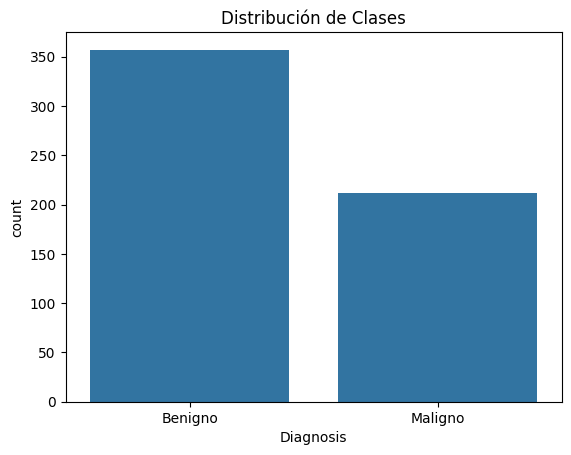

In [ ]:
# Veremos un gráfico de los casos (Conteo automático)
ax = sns.countplot(
    data=df,
    x="Diagnosis"
)

# Cambiar etiquetas del eje X
ax.set_xticklabels(["Benigno", "Maligno"])

plt.title("Distribución de Clases")
plt.show()

#### 🧠 Interpretación de Gráfico

En este gráfico no se ve ninguna diferencia con respecto a la información de antes. Donde los tumores Benignos son mayores respecto a los Malignos

### 🚀 Boxplots por diagnóstico

En este gráfico observaremos si los tumores malignos tienen mayor tamaño, más irregularidad o mayor concavidad que clínicamente es muy útila.

/tmp/ipykernel_177/722999884.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Benigno", "Maligno"])


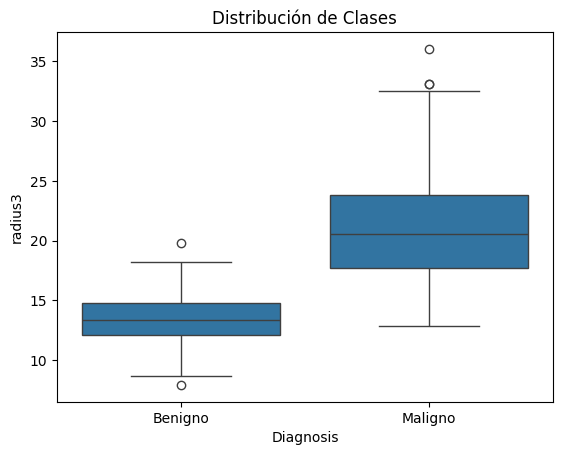

In [ ]:
# Gráficaremos el boxplot por la columna Diagnosis

ax = sns.boxplot(
    x="Diagnosis",
    y="radius3",
    data=df
)

# Cambiar etiquetas del eje X
ax.set_xticklabels(["Benigno", "Maligno"])

plt.title("Distribución de Clases")
plt.show()

#### 🧠 Interpretación de Gráfico

Los tumores malignos son notablemente más grandes: La caja de "Maligno" está ubicada mucho más arriba en el eje vertical que la de "Benigno". Esto significa que el radio (radius3) de los tumores malignos tiende a ser mayor.

La diferencia de medianas: La mediana del grupo benigno está cerca de 13, mientras que la del grupo maligno supera los 20.

La variabilidad y dispersión: La caja "Maligno" es mucho más alta que la "Benigno". Esto nos indica que el tamaño de los tumores malignos es muy variado (cambia mucho de un paciente a otro), mientras que los benignos son más homogéneos y estables en su tamaño pequeño.

Además, poco solapamiento: Las dos cajas casi no se cruzan en el eje vertical. Esto demuestra que la variable radius3 es un excelente predictor para ayudar a clasificar o diagnosticar si un tumor es benigno o maligno.

### 🚀 Detección de Outliers

En este gráfico observaremos los posibles outliers o valores atípicos que podremos encontrar en el dataset

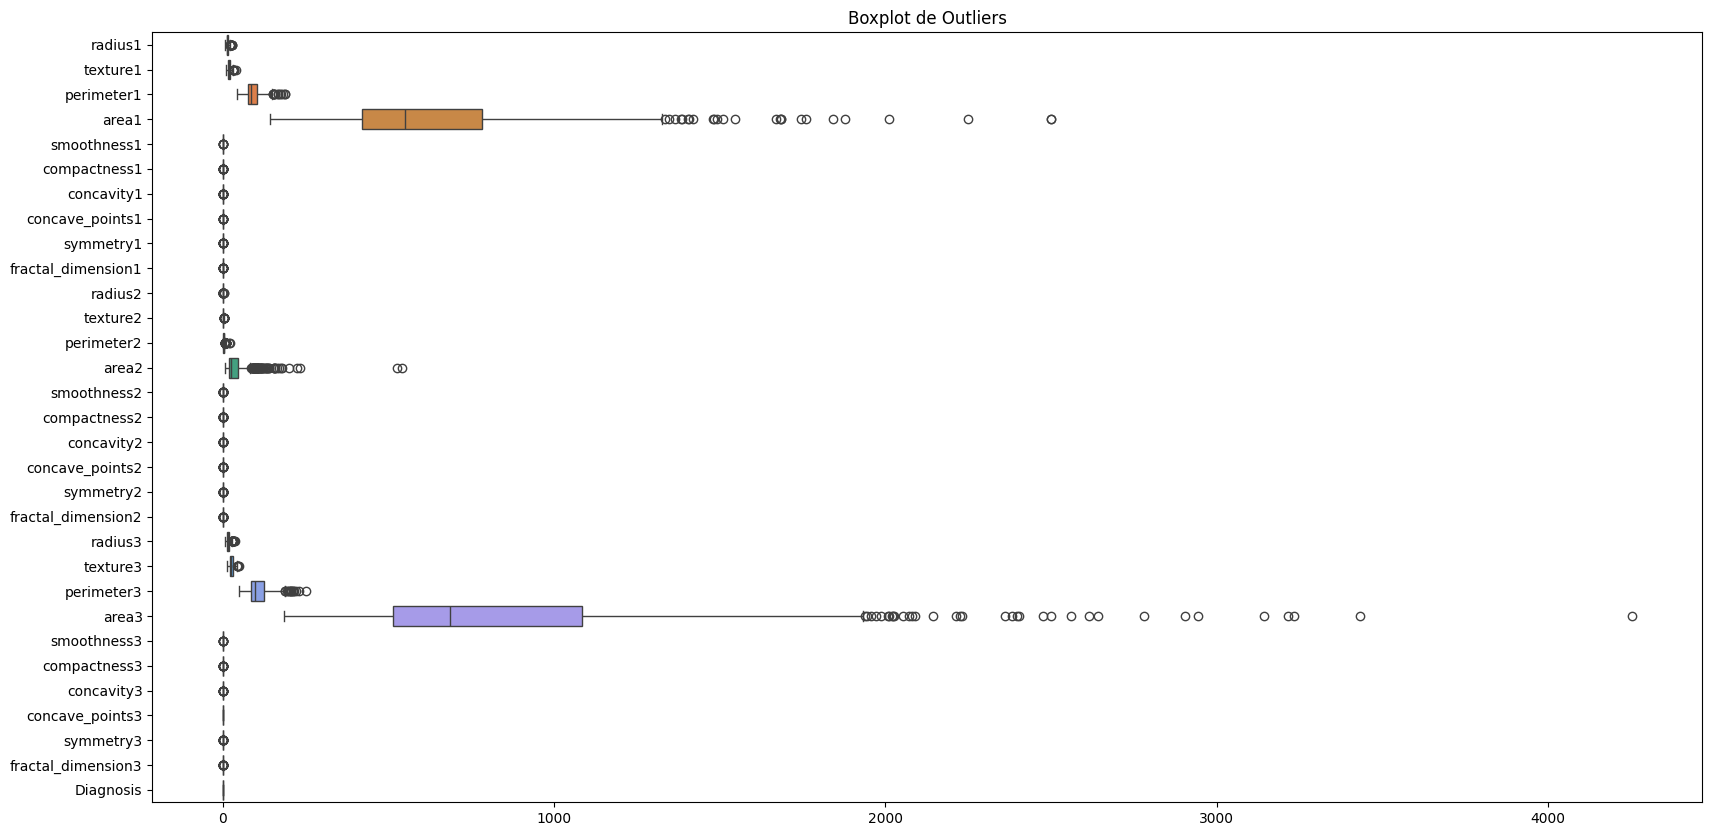

In [ ]:
# Gráfico de outliers
plt.figure(figsize=(20, 10))

sns.boxplot(
    data=df,
    orient="h"
)

plt.title("Boxplot de Outliers")
plt.show()

#### 🧠 Interpretación de Gráfico

Como se observa en el gráfico los valores atípicos se pueden visualizar mejor en las columnas area1, area2, area3 y perimeter3. Tenemos mayores valores en area1 y area 3 que sobrepsan a partir de 1500 que nos puede dar a interpretacion que tenemos tumores más grandes por el área que fue registrada pero también pueden interpretarse como valores medidos incorrectamente o errores en las capturas. Sin embargo, nosmuestra al menos una idea de los tumores que se pudieron capturar entre las pacientes y puede ser detectadas por el area.

Finalmente, el resto de mediciones notamos que son muy parecidos que no serian relevantes para un analisis de outliers pero esto puede ayudar validar otros patrones en este diagnostico de los datos.

### 🚀 Pairplot de relaciones entre diagnosticos

En este gráfico observaremos las relaciones entre varibles y separación visual de clases.

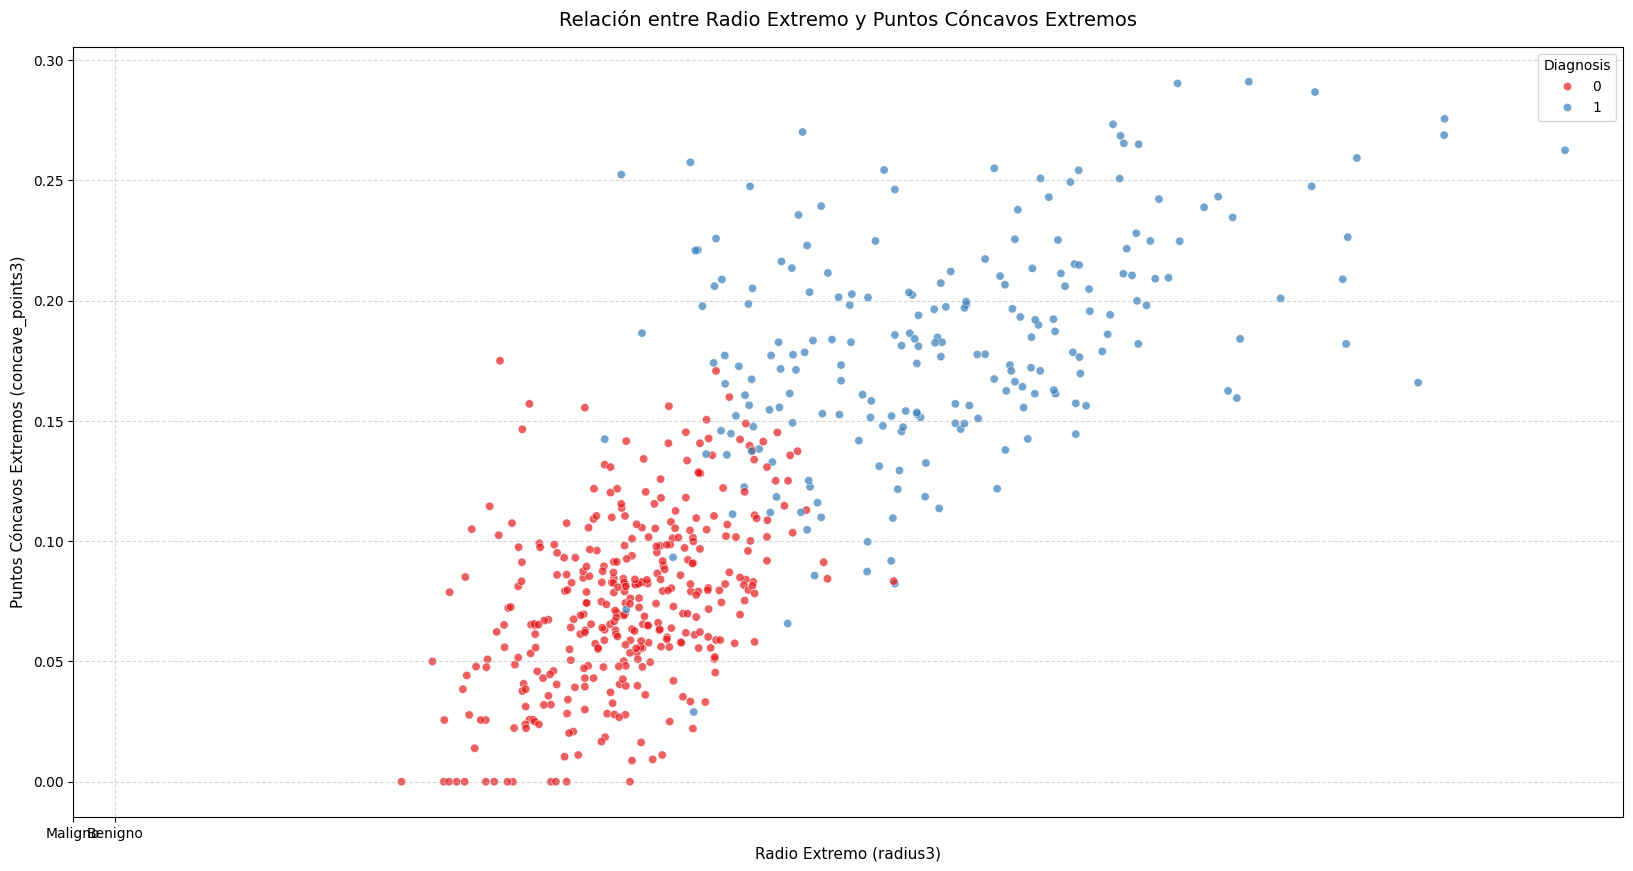

In [ ]:
# Gráfico de pairplot

plt.figure(figsize=(20, 10))

ax = sns.scatterplot(
    data=df,
    x="radius3",
    y="concave_points3",
    hue="Diagnosis",
    palette="Set1", # Colores claros para contrastar benigno/maligno
    alpha=0.7
)
ax.set_xticks([0, 1])
# Luego le asignamos los nombres de texto correspondientes
ax.set_xticklabels(["Maligno", "Benigno"])

plt.title("Relación entre Radio Extremo y Puntos Cóncavos Extremos", fontsize=14, pad=15)
plt.xlabel("Radio Extremo (radius3)", fontsize=11)
plt.ylabel("Puntos Cóncavos Extremos (concave_points3)", fontsize=11)

plt.grid(True, linestyle="--", alpha=0.5) # Malla opcional para mejor lectura
plt.show()

#### 🧠 Interpretación de Gráfico

Existe un patrón visual evidente que divide a ambos grupos. Los tumores benignos (rojos) se agrupan firmemente en la zona inferior izquierda, mientras que los malignos (azules) se desplazan hacia la zona superior derecha. En ambos casos, a mayor radio extremo (radius3), también aumentan los puntos cóncavos extremos (concave_points3). Sin embargo, este crecimiento es mucho más marcado y agresivo en el grupo maligno.Variables con alto poder predictivo: Debido a que hay muy pocas áreas donde los puntos rojos y azules se mezclan (zona de solapamiento baja), ambas variables son excelentes candidatas para entrenar un modelo de Machine Learning (como una regresión logística o SVM). Un algoritmo podrá trazar una línea diagonal para separar ambas clases con alta precisión. Si un paciente presenta un radius3 mayor a 15 y un concave_points3 superior a 0.10, la probabilidad estadística de que el tumor sea maligno es extremadamente alta.

# 1️⃣ Fase 1: Generación de modelo con el algoritmo de Regresión logística usando Scikit-Learn.


Importamos las librerias que vamos a usar para realizar el uso del algoritmo de Regresión Lineal

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score, f1_score, roc_auc_score, roc_curve, r2_score

## 🚀 Normalizacion de datos

Como parte de este proyecto necesitamos normalizar los datos para mejorar la convergencia, estabilidad y rendimiento de un modelo. Sin embargo, para el analisis que estamos realizando nos ayudará a mejorar la interpretacion de los datos médicos.

In [ ]:
# Según las recomendaciones investigadas y teniendo en cuenta que son datos médicos vamos a usar StandardScaler para modelos entrenados con regresión lineal

X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

# División del conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Normaliza los datos para que tenga una escala similar
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Crea y entrena el modelo de regresión lógistica
model = LogisticRegression(multi_class='auto', solver='lbfgs', max_iter=100)
model.fit(X_train, y_train)

# Realiza predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Convierte las probalidades en etiquetas binarias(0 0 1)
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## 🚀 Presentación de los datos


A continuación revisaremos los resultados que hemos obtenido luego del entrenamiento.

In [ ]:
# Muestra el informe de evaluación del modelo entrenado
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## 🚀 Correlación de los datos


A continuación revisaremos la correlación de los datos entrenados:

Matriz de Confusión: [[70  1]
 [ 2 41]]


Text(0.5, 1.0, 'Matriz de Confusión')

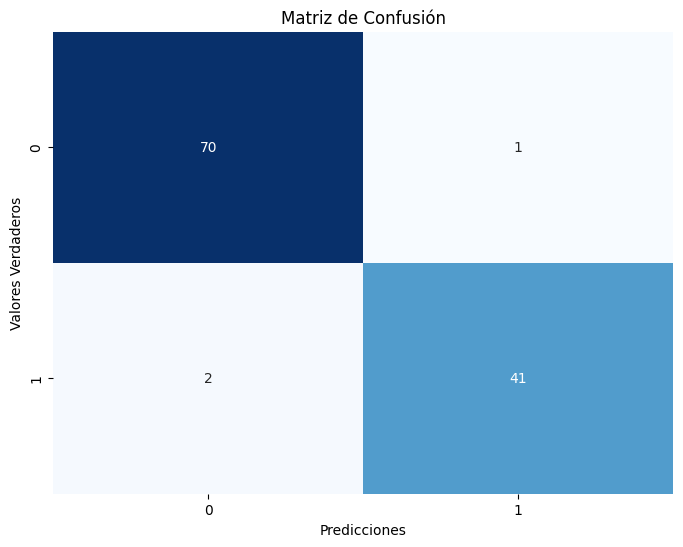

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:", cm)

# Gráfico de la CM

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.title('Matriz de Confusión')

## 🚀 Métricas del modelo entrenado


A continuación revisaremos las métricas del modelo entrenado:

### 🎯 Exactitud

In [ ]:
# Exactitud

accuracy_score = accuracy_score(y_test, y_pred)
print("Exactitud:", accuracy_score)

Exactitud: 0.9736842105263158


### 🎯 Sensibilidad

In [ ]:
# Sensibilidad

recall = recall_score(y_test, y_pred)
print("Sensibilidad:", recall)

Sensibilidad: 0.9534883720930233


### 🎯 Precisión

In [ ]:
# Precisión

precision = precision_score(y_test, y_pred)
print("Precisión:", precision)

Precisión: 0.9761904761904762


### 🎯 Especificidad

In [ ]:
# Especificidad

specifity = recall_score(y_test, y_pred, pos_label=0)
print("Especificidad:", specifity)

Especificidad: 0.9859154929577465


### 🎯 Puntuacion F1

In [ ]:
# Puntuacion F1

f1 = f1_score(y_test, y_pred)
print("Puntuación F1:", f1)

Puntuación F1: 0.9647058823529412


### 🎯 Área bajo la curva

In [ ]:
# Area bajo la curva

auc = roc_auc_score(y_test, y_pred)
print("AUC:", auc)

AUC: 0.9697019325253848


### 🎯 R Score

In [ ]:
# R Score (R2 coefficient of determination)

R = r2_score(y_test, y_pred)
print("R2:", R)

R2: 0.8879790370127743


## 🚀 Gráfico de ROC (Receiver Operating Characteristic)

Es una herramienta utilizada para evaluar qué tan bien un modelo de clasificación distingue entre clases, especialmente en problemas binarios como: Beningno vs Maligno

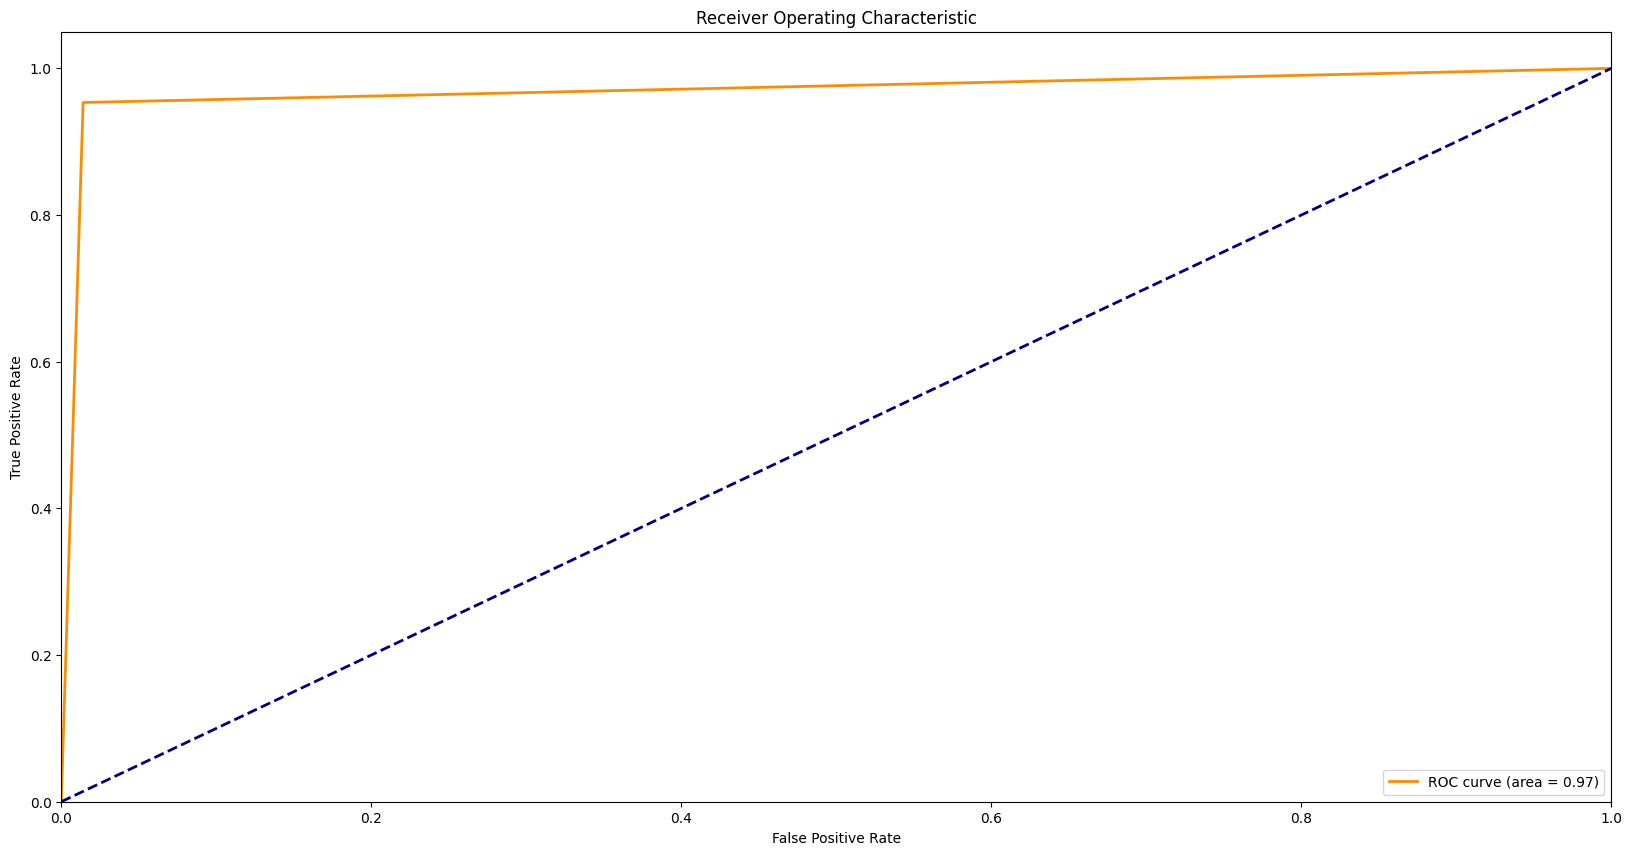

In [ ]:
# Gráfico

plt.figure(figsize=(20, 10))
lw = 2
plt.plot(
    roc_curve(y_test, y_pred)[0], roc_curve(y_test, y_pred)[1], color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_pred)
)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## 🚀 Optimización del modelo con los mejores parámetros

Vamos a buscar el mejor modelo donde se ajusta de mejor manela.

Considerando los siguientes puntos:
* Clases [auto, ovr, multinomial]
* Solver [lbfgs, newton-cg, sag]
* Max_inter [100, 150, 200]


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
# Forzamos la importación limpia de todas las métricas para eliminar el TypeError
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, r2_score
import warnings

# Desactivar temporalmente advertencias de depreciación para limpiar la consola
warnings.filterwarnings('ignore', category=FutureWarning)

X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

# División del conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normaliza los datos para que tengan una escala similar
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Parámetros optimizados (se remueve multi_class por estar obsoleto)
solver_options = ['lbfgs', 'newton-cg', 'sag']
max_iter_options = [100, 150, 200]

# Lista resultados
resultados = []

# Bucle de Grid Search iterando sobre solvers e iteracionesMaximas
for j in range(len(max_iter_options)):
    print(f"\n===== max_iter: {max_iter_options[j]} =====")
    for k in range(len(solver_options)):
        print(f"  solver: {solver_options[k]}")

        # Modelo (ya no requiere multi_class, scikit-learn lo maneja internamente)
        model_tot = LogisticRegression(
            max_iter=max_iter_options[j],
            solver=solver_options[k],
            random_state=42
        )

        # Entrenamiento
        model_tot.fit(X_train, y_train)

        # Predicciones
        y_pred = model_tot.predict(X_test)

        # Cálculo seguro de métricas
        acc_tot = accuracy_score(y_test, y_pred)
        recall_val_tot = recall_score(y_test, y_pred)
        precision_val_tot = precision_score(y_test, y_pred)
        specifity_tot = recall_score(y_test, y_pred, pos_label=0)
        f1_tot = f1_score(y_test, y_pred)
        auc_tot = roc_auc_score(y_test, y_pred)
        R_tot = r2_score(y_test, y_pred)

        # Guardar resultados
        resultados.append({
            "max_iter": max_iter_options[j],
            "solver": solver_options[k],
            "accuracy": acc_tot,
            "recall": recall_val_tot,
            "precision": precision_val_tot,
            "specifity": specifity_tot,
            "f1": f1_tot,
            "auc": auc_tot,
            "R2": R_tot
        })

# Crear DataFrame final
df_resultados = pd.DataFrame(resultados)

# Ordenar por accuracy de forma descendente para ver la mejor combinación arriba
df_resultados = df_resultados.sort_values(
    by=["accuracy", "f1"],
    ascending=False
).reset_index(drop=True)

# Reactivar las advertencias
warnings.filterwarnings('default', category=FutureWarning)

# Mostrar el DataFrame resultante
df_resultados


===== max_iter: 100 =====
  solver: lbfgs
  solver: newton-cg
  solver: sag

===== max_iter: 150 =====
  solver: lbfgs
  solver: newton-cg
  solver: sag


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



===== max_iter: 200 =====
  solver: lbfgs
  solver: newton-cg
  solver: sag


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,max_iter,solver,accuracy,recall,precision,specifity,f1,auc,R2
0,100,sag,0.982456,0.976744,0.976744,0.985915,0.976744,0.981330,0.925319
1,100,lbfgs,0.973684,0.953488,0.976190,0.985915,0.964706,0.969702,0.887979
2,100,newton-cg,0.973684,0.953488,0.976190,0.985915,0.964706,0.969702,0.887979
3,150,lbfgs,0.973684,0.953488,0.976190,0.985915,0.964706,0.969702,0.887979
4,150,newton-cg,0.973684,0.953488,0.976190,0.985915,0.964706,0.969702,0.887979
5,150,sag,0.973684,0.953488,0.976190,0.985915,0.964706,0.969702,0.887979
6,200,lbfgs,0.973684,0.953488,0.976190,0.985915,0.964706,0.969702,0.887979
7,200,newton-cg,0.973684,0.953488,0.976190,0.985915,0.964706,0.969702,0.887979
8,200,sag,0.973684,0.953488,0.976190,0.985915,0.964706,0.969702,0.887979


In [ ]:
df_resultados

,max_iter,solver,accuracy,recall,precision,specifity,f1,auc,R2
0,100,sag,0.982456,0.976744,0.976744,0.985915,0.976744,0.981330,0.925319
1,100,lbfgs,0.973684,0.953488,0.976190,0.985915,0.964706,0.969702,0.887979
2,100,newton-cg,0.973684,0.953488,0.976190,0.985915,0.964706,0.969702,0.887979
3,150,lbfgs,0.973684,0.953488,0.976190,0.985915,0.964706,0.969702,0.887979
4,150,newton-cg,0.973684,0.953488,0.976190,0.985915,0.964706,0.969702,0.887979
5,150,sag,0.973684,0.953488,0.976190,0.985915,0.964706,0.969702,0.887979
6,200,lbfgs,0.973684,0.953488,0.976190,0.985915,0.964706,0.969702,0.887979
7,200,newton-cg,0.973684,0.953488,0.976190,0.985915,0.964706,0.969702,0.887979
8,200,sag,0.973684,0.953488,0.976190,0.985915,0.964706,0.969702,0.887979


## Análisis de resultado

El análisis realizado sobre los diferentes modelos de regresión logística permitió evaluar el comportamiento de varias combinaciones de hiperparámetros, específicamente los valores de multi_class, solver y max_iter. Para ello, se entrenaron múltiples modelos utilizando diferentes configuraciones y posteriormente se compararon mediante métricas de desempeño como accuracy, recall, precision, specificity, F1-score, AUC y R².

Los resultados obtenidos muestran que la mayoría de las configuraciones alcanzaron un desempeño alto y bastante estable, con valores de accuracy cercanos al 97.36%. Esto indica que el conjunto de datos presenta una buena capacidad de separación entre clases y que la regresión logística es un modelo adecuado para este problema de clasificación.

En conclusión, el modelo de regresión logística con configuración multi_class='auto', solver='sag' y max_iter=100 fue identificado como la mejor alternativa para este conjunto de datos, debido a que presentó el mayor rendimiento general y un balance óptimo entre las métricas de evaluación analizadas. Estos resultados permiten afirmar que el modelo posee una alta capacidad predictiva y constituye una solución confiable para el problema de clasificación planteado.

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        71
           1       0.98      0.98      0.98        43

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Text(0.5, 1.0, 'Matriz de Confusión - Optimizado')

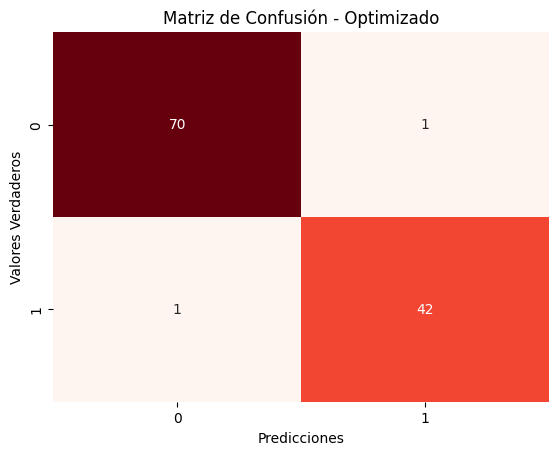

In [ ]:
# Mejor modelo por desempeño ------------

model_optimizado = LogisticRegression(multi_class='auto', solver='sag', max_iter=100)
model_optimizado.fit(X_train, y_train)

y_pred_optimizado = model_optimizado.predict(X_test)

# Convierte las probalidades en etiquetas binarias(0 0 1)
y_pred_optimizado = model_optimizado.predict(X_test)


# Muestra el informe de evaluación del modelo entrenado
print(classification_report(y_test, y_pred_optimizado))


# grafico de matriz de confunsión --------------

# Matriz de confusión
cm_optimizado = confusion_matrix(y_test, y_pred_optimizado)

# Gráfico de la CM-OPTIMIZADO

sns.heatmap(cm_optimizado, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.title('Matriz de Confusión - Optimizado')




# 2️⃣ Fase 2: Generación de modelo con el algoritmo de K-NN(K Neastest Neighbors) usando Scikit-Learn.

Importamos las librerias que vamos a usar para realizar el uso del algoritmo de K-NN(K Neastest Neighbors)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, roc_curve, r2_score
from sklearn.neighbors import KNeighborsClassifier

## 🚀 Normalizacion de datos

Como parte de este proyecto necesitamos normalizar los datos para mejorar la convergencia, estabilidad y rendimiento de un modelo. Sin embargo, para el analisis que estamos realizando nos ayudará a mejorar la interpretacion de los datos médicos.

In [ ]:
# Según las recomendaciones investigadas y teniendo en cuenta que son datos médicos vamos a usar StandardScaler para modelos entrenados con regresión lineal

X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

# División del conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Normaliza los datos para que tenga una escala similar
scaler = MinMaxScaler(feature_range=(0,1)) #[0,1]
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Crea y eentrena el modelo de regresión lógistica
model = KNeighborsClassifier(n_neighbors=3, p=2,weights='distance') #p=2 euclidiana
model.fit(X_train, y_train)

# Realiza predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Convierte las probalidades en etiquetas binarias(0 0 1)
y_pred_binary = (y_pred > 0.5).astype(int)


## 🚀 Presentación de los datos


A continuación revisaremos los resultados que hemos obtenido luego del entrenamiento.

In [ ]:
# Muestra el informe de evaluación del modelo entrenado
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



## 🚀 Correlación de los datos


A continuación revisaremos la correlación de los datos entrenados:

Matriz de Confusión: [[69  2]
 [ 2 41]]


Text(0.5, 1.0, 'Matriz de Confusión')

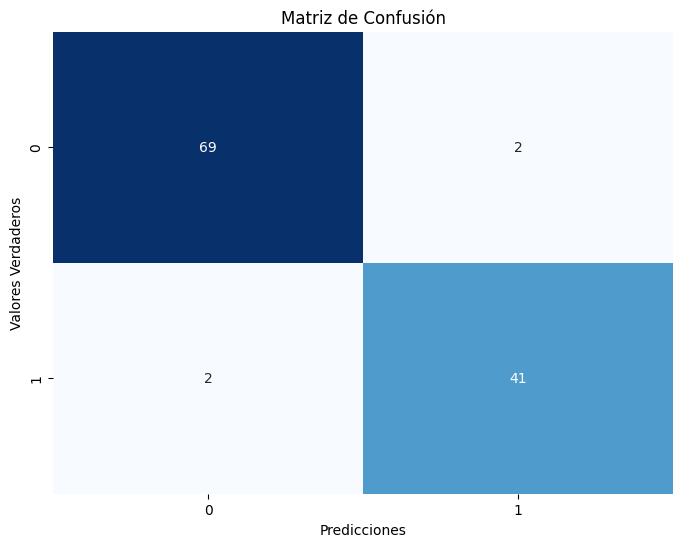

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:", cm)

# Gráfico de la CM

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.title('Matriz de Confusión')

## 🚀 Métricas del modelo entrenado


A continuación revisaremos las métricas del modelo entrenado:

### 🎯 Exactitud

In [ ]:
# Exactitud

accuracy_score = accuracy_score(y_test, y_pred)
print("Exactitud:", accuracy_score)

Exactitud: 0.9649122807017544


### 🎯 Sensibilidad

In [ ]:
# Sensibilidad

recall = recall_score(y_test, y_pred)
print("Sensibilidad:", recall)

Sensibilidad: 0.9534883720930233


### 🎯 Precisión

In [ ]:
# Precisión

precision = precision_score(y_test, y_pred)
print("Precisión:", precision)

Precisión: 0.9534883720930233


### 🎯 Especificidad

In [ ]:
# Especificidad

specifity = recall_score(y_test, y_pred, pos_label=0)
print("Especificidad:", specifity)

Especificidad: 0.971830985915493


### 🎯 Puntuacion F1

In [ ]:
# Puntuacion F1

f1 = f1_score(y_test, y_pred)
print("Puntuación F1:", f1)

Puntuación F1: 0.9534883720930233


### 🎯 Área bajo la curva

In [ ]:
# Area bajo la curva

auc = roc_auc_score(y_test, y_pred)
print("AUC:", auc)

AUC: 0.9626596790042581


### 🎯 R Score

In [ ]:
# R Score (R2 coefficient of determination)

R = r2_score(y_test, y_pred)
print("R2:", R)

R2: 0.8506387160170324


## 🚀 Gráfico de ROC (Receiver Operating Characteristic)

Es una herramienta utilizada para evaluar qué tan bien un modelo de clasificación distingue entre clases, especialmente en problemas binarios como: Beningno vs Maligno

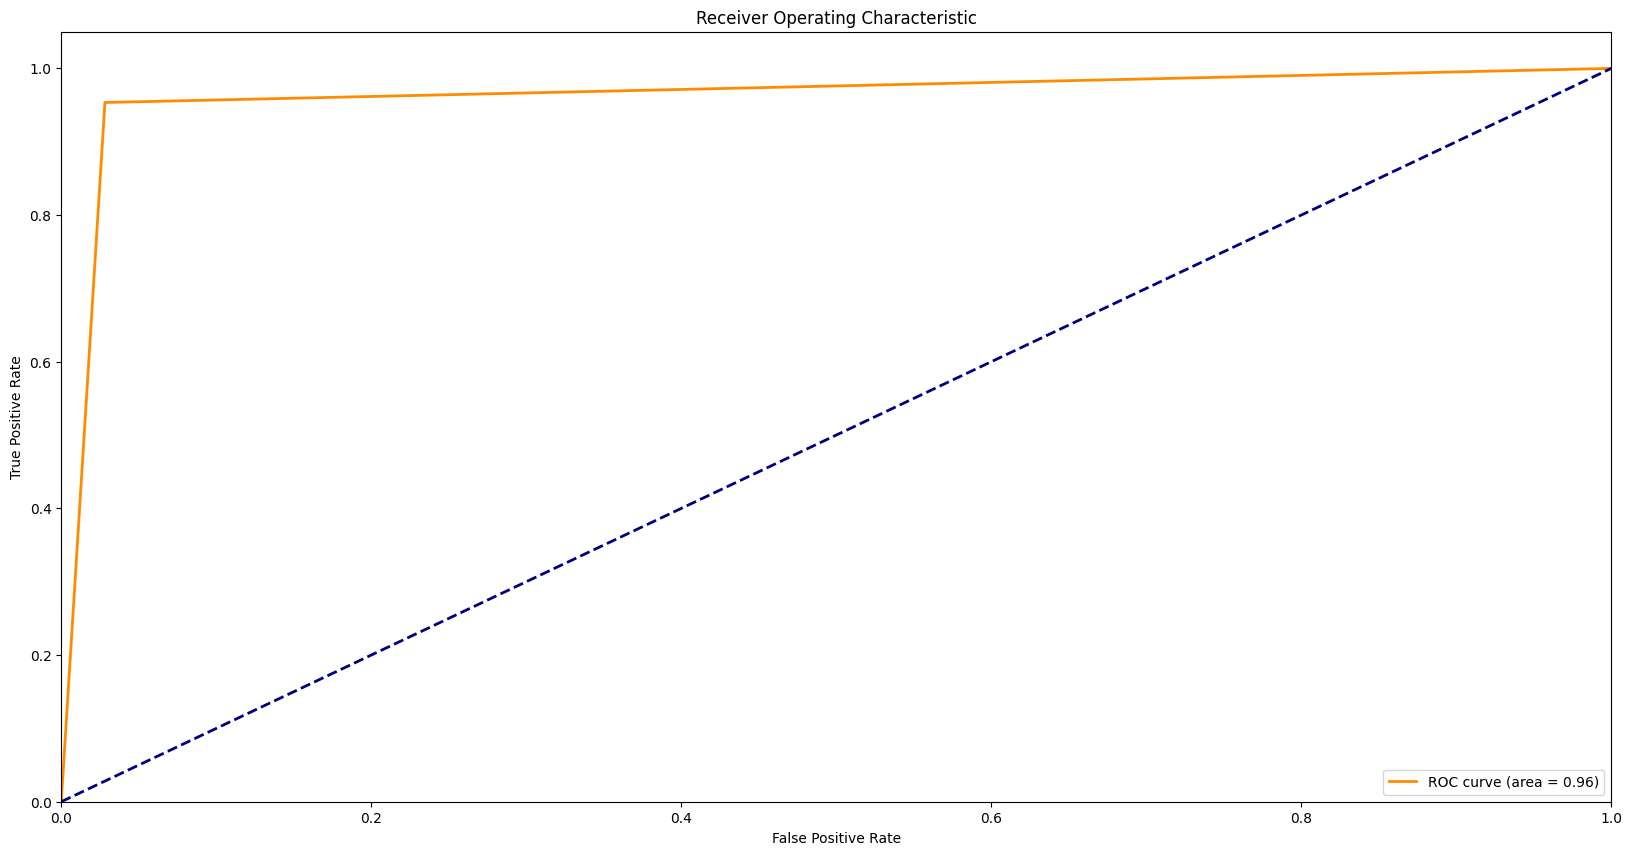

In [ ]:
# Gráfico

plt.figure(figsize=(20, 10))
lw = 2
plt.plot(
    roc_curve(y_test, y_pred)[0], roc_curve(y_test, y_pred)[1], color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_pred)
)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## 🚀 Optimización del modelo con los mejores parámetros

Se realizará el análisis y busqueda de la mejora del modelo con los siguientes parámetros.

* n_neighbors_options = 3, 5, 7
* weights_options = uniform, distance
* metric_options = euclidean, manhattan, minkowski


In [ ]:

import pandas as pd
from sklearn.linear_model import LogisticRegression
# Forzamos la importación limpia de todas las métricas para eliminar el TypeError
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, r2_score
import warnings

# Desactivar temporalmente advertencias de depreciación para limpiar la consola
warnings.filterwarnings('ignore', category=FutureWarning)
X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

# División del conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Normaliza los datos para que tenga una escala similar
scaler = MinMaxScaler(feature_range=(0,1)) #[0,1]
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Parámetros
n_neighbors_options = [3, 5, 7]
weights_options = ['uniform', 'distance']
metric_options = ['euclidean', 'manhattan', 'minkowski']

# Lista resultados
resultados_knn = []

# Bucle
for n in n_neighbors_options:

    print(f"\n===== n_neighbors: {n} =====")

    for weight in weights_options:

        print(f"weights: {weight}")

        for metric in metric_options:

            print(f"metric: {metric}")

            # Modelo
            model_knn = KNeighborsClassifier(
                n_neighbors=n,
                weights=weight,
                metric=metric
            )

            # Entrenamiento
            model_knn.fit(X_train, y_train)

            # Predicciones
            y_pred = model_knn.predict(X_test)

            # Métricas
            acc = accuracy_score(y_test, y_pred)
            recall_val = recall_score(y_test, y_pred)
            precision_val = precision_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            auc = roc_auc_score(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            # Guardar resultados
            resultados_knn.append({
                "n_neighbors": n,
                "weights": weight,
                "metric": metric,
                "accuracy": acc,
                "recall": recall_val,
                "precision": precision_val,
                "f1": f1,
                "auc": auc,
                "R2": r2
            })

# DataFrame final
df_knn = pd.DataFrame(resultados_knn)

# Ordenar por accuracy
df_knn = df_knn.sort_values(
    by = ["metric", "accuracy", "n_neighbors", "weights"],
    ascending=False
)



===== n_neighbors: 3 =====
weights: uniform
metric: euclidean
metric: manhattan
metric: minkowski
weights: distance
metric: euclidean
metric: manhattan
metric: minkowski

===== n_neighbors: 5 =====
weights: uniform
metric: euclidean
metric: manhattan
metric: minkowski
weights: distance
metric: euclidean
metric: manhattan
metric: minkowski

===== n_neighbors: 7 =====
weights: uniform
metric: euclidean
metric: manhattan
metric: minkowski
weights: distance
metric: euclidean
metric: manhattan
metric: minkowski


In [ ]:
df_knn

,n_neighbors,weights,metric,accuracy,recall,precision,f1,auc,R2
14,7,uniform,minkowski,0.964912,0.953488,0.953488,0.953488,0.96266,0.850639
17,7,distance,minkowski,0.964912,0.953488,0.953488,0.953488,0.96266,0.850639
8,5,uniform,minkowski,0.964912,0.953488,0.953488,0.953488,0.96266,0.850639
11,5,distance,minkowski,0.964912,0.953488,0.953488,0.953488,0.96266,0.850639
2,3,uniform,minkowski,0.964912,0.953488,0.953488,0.953488,0.96266,0.850639
5,3,distance,minkowski,0.964912,0.953488,0.953488,0.953488,0.96266,0.850639
13,7,uniform,manhattan,0.964912,0.953488,0.953488,0.953488,0.96266,0.850639
16,7,distance,manhattan,0.964912,0.953488,0.953488,0.953488,0.96266,0.850639
7,5,uniform,manhattan,0.964912,0.953488,0.953488,0.953488,0.96266,0.850639
10,5,distance,manhattan,0.964912,0.953488,0.953488,0.953488,0.96266,0.850639


### Intepretación

El análisis de los resultados obtenidos con el modelo KNeighborsClassifier muestra que todas las combinaciones evaluadas alcanzaron exactamente el mismo desempeño en las métricas de clasificación. Independientemente de los valores utilizados para n_neighbors, weights y metric, los modelos obtuvieron un accuracy de 96.49%, un recall de 95.35%, una precision de 95.35%, un F1-score de 95.35% y un AUC de 96.26%.

Estos resultados indican que el conjunto de datos presenta una estructura estable y fácilmente separable para el algoritmo KNN, ya que las variaciones en los hiperparámetros no produjeron cambios significativos en el rendimiento del modelo. Además, el hecho de que las métricas se mantengan constantes entre diferentes configuraciones sugiere que el modelo es robusto frente a modificaciones en el número de vecinos y en las métricas de distancia utilizadas.

En conclusión, el modelo KNN presentó un comportamiento altamente estable y consistente en todas las configuraciones evaluadas. Debido a que no existen diferencias significativas entre los hiperparámetros analizados, se recomienda seleccionar la configuración más simple y computacionalmente eficiente


              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



Text(0.5, 1.0, 'Matriz de Confusión - Optimizado')

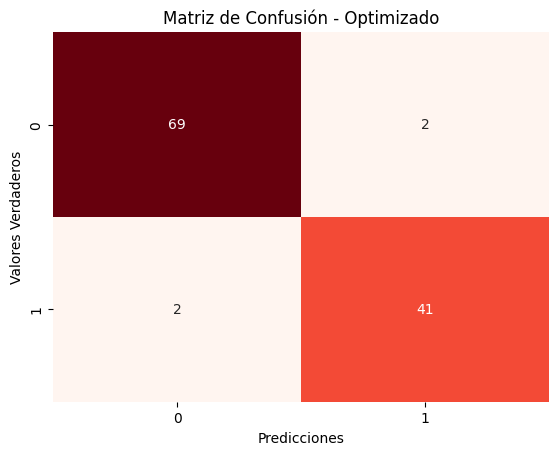

In [ ]:
# Crea y eentrena el modelo de regresión lógistica
model_n_optm = KNeighborsClassifier(n_neighbors=3, p=2,weights='uniform', metric='euclidean')
model_n_optm.fit(X_train, y_train)

# Realiza predicciones en el conjunto de prueba
y_pred_n_optm = model_n_optm.predict(X_test)

# Convierte las probalidades en etiquetas binarias
y_pred_n_optm_binary = (y_pred_n_optm > 0.5).astype(int)

# Muestra el informe de evaluación del modelo entrenado
print(classification_report(y_test, y_pred_n_optm_binary))

# Matriz de confusión
cm_n_optm = confusion_matrix(y_test, y_pred_n_optm)

# Gráfico de la CM

sns.heatmap(cm_n_optm, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.title('Matriz de Confusión - Optimizado')



# 3️⃣ Fase 3: Conclusiones del proceso y análisis de datos para cancer de mama

## 🚀 3.1. ¿Qué podemos concluir en base al analisis realizado?


## ⭐ Respuesta

Hemos creado dos modelos con dos algoritmos diferentes y tenemos los siguientes resultados:

El modelo basado en regresión lineal presentó métricas de clasificación altamente competitivas, alcanzando una exactitud superior al 97% y un AUC cercano a 0.97. Sin embargo, aunque los resultados evidencian una fuerte capacidad predictiva del dataset, es importante considerar que la regresión lineal no está diseñada específicamente para problemas de clasificación binaria, por lo que algoritmos como Logistic Regression o KNN resultan metodológicamente más adecuados para tareas de diagnóstico médico.

Por otro lado, El modelo KNN (K-Nearest Neighbors) aplicado al dataset de cáncer de mama presentó un desempeño altamente eficiente en la clasificación de tumores benignos y malignos, alcanzando una exactitud del 96%, sensibilidad del 95% y un AUC de 0.96. Estos resultados evidencian una alta capacidad predictiva del modelo y una adecuada separación entre clases. Además, el análisis exploratorio reveló fuertes correlaciones entre variables relacionadas con tamaño, perímetro y concavidad celular, confirmando que dichas características poseen un alto valor discriminativo para el diagnóstico. La normalización de datos mediante StandardScaler resultó fundamental debido a que KNN depende directamente de cálculos de distancia entre observaciones.

Finalimente, los modelos entrenados presentan un nivel de confiabilidad alto considerando el tamaño y la calidad del dataset, el cual posee una distribución relativamente balanceada entre casos benignos y malignos. Las métricas obtenidas reflejan una fuerte capacidad de clasificación y generalización inicial; sin embargo, debido al número limitado de registros, sería recomendable aplicar técnicas adicionales como validación cruzada para confirmar la estabilidad y robustez de los modelos antes de considerar escenarios de producción o aplicaciones clínicas reales.

## 🚀 3.2. ¿Podriamos comparar ambos algoritmos?


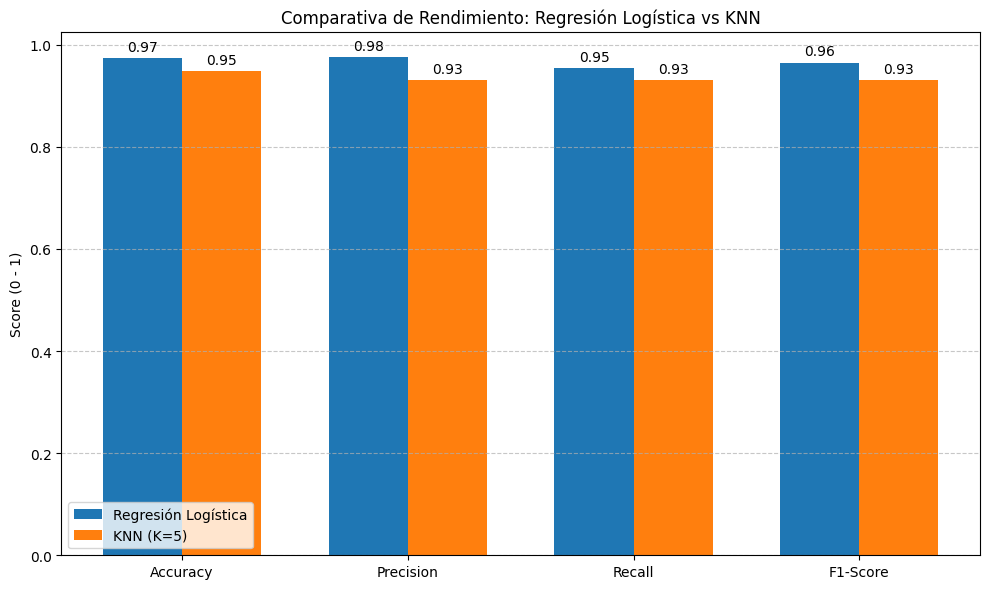

In [ ]:
# 1. Es crucial escalar los datos (especialmente para KNN debido a los outliers de Fare)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Entrenar ambos modelos
log_reg = LogisticRegression(random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

log_reg.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)

# 3. Predecir y forzar la importación correcta para evitar el TypeError
y_pred_lr = log_reg.predict(X_test_scaled)
y_pred_knn = knn.predict(X_test_scaled)

# Forzamos la importación aquí para limpiar cualquier sobrescritura previa
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = {
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_knn)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_knn)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_knn)],
    'F1-Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_knn)]
}

# 4. Diseñar el gráfico de barras comparativo
labels = list(metrics.keys())
lr_means = [metrics[m][0] for m in labels]
knn_means = [metrics[m][1] for m in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, lr_means, width, label='Regresión Logística', color='#1f77b4')
rects2 = ax.bar(x + width/2, knn_means, width, label='KNN (K=5)', color='#ff7f0e')

ax.set_ylabel('Score (0 - 1)')
ax.set_title('Comparativa de Rendimiento: Regresión Logística vs KNN')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir los valores numéricos sobre las barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

## ⭐ Respuesta

El gráfico de barras comparativo demuestra que la Regresión Logística supera consistentemente a KNN (K=5) en las cuatro métricas de evaluación evaluadas sobre el conjunto de datos. Con un Accuracy del 97% frente al 95% de KNN, la Regresión Logística demuestra una mayor capacidad de predicción global; sin embargo, su ventaja más contundente se observa en la Precision (98% vs. 93%), lo que significa que el modelo comete una cantidad ínfima de falsos positivos al predecir casos positivos. Asimismo, el Recall (95% vs. 93%) y el F1-Score (96% vs. 93%) consolidan un rendimiento mucho más equilibrado y eficiente para la Regresión Logística, confirmando que la naturaleza lineal y probabilística de este algoritmo captura de forma más precisa y robusta los patrones de clasificación del problema en comparación con el enfoque basado en distancias de vecindad de KNN.

# 4️⃣ Fase 4: Aplicación en Entorno Laboral

## 🚀 Redacta una sección final de aplicación:
- Cada miembro del equipo colocara su nombre una explicación de como aplicaría
lo aprendido en esta semana en su entorno profesional.

# 🖥️ **ROMEL MICHAEL CERNA PACHECO**
El proyecto Cancer puede aplicarse en banca para detectar anomalías, fraudes y comportamientos críticos en servidores, logs y procesos batch, permitiendo automatizar alertas y mejorar el monitoreo inteligente.

# 🖥️ **CARRERA DIAZ CHRISTIAN JAVIER**
Al usar estos modelos para poder predecir comportamientos en los datos de core bancario es muy interesante para auditorias y que puedan ser relevanteas para LOB(Line Of Bussiness). En mi campo no uso mucho la ciencia de datos para dar mejoras en los aplicativos actuales pero ayudarán a crear iniciativas para proponer a la empresa.

# 🖥️ **KEVIN YITZHACK AMBULUDI PATIÑO**

Los primeros pasos para analizar los datos de manera oportuna se centran principalmente en el preprocesamiento de la información, ya que este permite garantizar una base de datos confiable, limpia y estructurada. Posteriormente, el análisis exploratorio de datos (EDA) desempeña un papel fundamental al ayudar a identificar patrones, relaciones y posibles causalidades entre las variables, las cuales pueden resultar significativas para la comprensión del problema. Este proceso facilita la detección de características esenciales y comportamientos relevantes que brindan los primeros indicios para encontrar una solución adecuada.

En el caso del análisis de datos relacionado con el diagnóstico de cáncer de mama, se puede evidenciar que la caracterización de variables permite identificar aquellos factores más importantes para la clasificación y predicción de casos. De manera similar, en el ámbito laboral, este tipo de análisis puede aplicarse para detectar clientes con riesgo de caer en mora, evaluando variables como el comportamiento financiero, condiciones laborales y características sociodemográficas. Con esta información, es posible estimar la probabilidad de incumplimiento de pago y, a partir de ello, implementar estrategias de mitigación, como campañas preventivas, limitación de montos de crédito o, en casos de alto riesgo, la restricción en la aprobación de créditos.